In [1]:
import sys
from pathlib import Path

import numpy as np
import networkx as nx
from bayesian_order_based_learning.metrics import *

sys.path.append(str(Path.cwd().parent / "bayesian_order_based_learning"))

In [2]:
from simulation.simulation import Simulation

/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-27 21:50:51,535	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [39]:
p = 10
sigma = np.arange(p)
np.random.shuffle(sigma)

sigma

array([7, 2, 3, 6, 8, 5, 0, 4, 9, 1])

In [40]:
sim = Simulation(sigma=sigma, n_k=1000, K_list=[1, 5, 10, 20], verbose=True)

predicted_orderings, predicted_dags, log_posteriors = sim.simulate()

true_dags = sim.get_true_dags()
true_datasets = sim.get_datasets()
true_posteriors = sim.get_true_posterior()


K=1 being computed ...



2026-08-27 21:56:24,304	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:56:24,316	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:56:24,320	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:56:24,321	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:11<00:00, 170.10it/s]



K=5 being computed ...



2026-08-27 21:56:40,233	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:56:40,244	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:56:40,248	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:56:40,249	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:16<00:00, 123.80it/s]



K=10 being computed ...



2026-08-27 21:57:01,601	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:57:01,612	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:57:01,617	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:57:01,618	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:21<00:00, 91.93it/s]



K=20 being computed ...



2026-08-27 21:57:27,780	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 21:57:27,790	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 21:57:27,795	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 21:57:27,796	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:39<00:00, 50.09it/s]


In [41]:
def get_adj_matrix(list_dags):
    return [nx.adjacency_matrix(dag, weight=None) for dag in list_dags]

true_adj_matrices = np.array(get_adj_matrix(true_dags[:1]))
true_adj_matrices2 = np.array(get_adj_matrix(true_dags[:5]))
true_adj_matrices3 = np.array(get_adj_matrix(true_dags[:10]))
true_adj_matrices4 = np.array(get_adj_matrix(true_dags[:20]))

predicted_adj_matrices = np.array([get_adj_matrix(dags) for dags in predicted_dags[0]])
predicted_adj_matrices2 = np.array([get_adj_matrix(dags) for dags in predicted_dags[1]])
predicted_adj_matrices3 = np.array([get_adj_matrix(dags) for dags in predicted_dags[2]])
predicted_adj_matrices4 = np.array([get_adj_matrix(dags) for dags in predicted_dags[3]])

In [42]:
hd = np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices])
hd2 = np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2])
hd3 = np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3])
hd4 = np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4])

In [43]:
hd, hd2, hd3, hd4

(np.float64(0.698),
 np.float64(0.95),
 np.float64(0.7787999999999999),
 np.float64(0.3668))

In [44]:
tau_star_K1 = rank_correlation(predicted_orderings[0], sigma)
tau_star_K5 = rank_correlation(predicted_orderings[1], sigma)
tau_star_K10 = rank_correlation(predicted_orderings[2], sigma)
tau_star_K20 = rank_correlation(predicted_orderings[3], sigma)

In [45]:
tau_star_K1, tau_star_K5, tau_star_K10, tau_star_K20

(np.float64(0.3116888888888881),
 np.float64(0.7396000000000009),
 np.float64(0.7965777777777776),
 np.float64(0.948888888888891))

In [30]:
def find_edges(predicted_dags, true_dags):
    common_edges = [[] for _ in true_dags]
    diff_edges = [[] for _ in true_dags]
    edges_not_counted = [[] for _ in true_dags]

    for k, dag in enumerate(true_dags):
        temp = predicted_dags[-1][k]

        for e in temp.edges():
            if e in dag.edges():
                common_edges[k].append(e)
            else:
                diff_edges[k].append(e)

        for e in dag.edges():
            if e not in temp.edges():
                edges_not_counted[k].append(e)

    return common_edges, diff_edges, edges_not_counted


In [46]:
common_edges, diff_edges, edges_not_counted = find_edges(predicted_dags[0], true_dags[:1])
print(f"Common edges: {common_edges}")
print(f"Different edges: {diff_edges}")
print(f"Unaccounted edges: {edges_not_counted}")

Common edges: [[(2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]]
Different edges: [[(1, 2)]]
Unaccounted edges: [[(2, 1)]]


In [47]:
common_edges2, diff_edges2, edges_not_counted2 = find_edges(predicted_dags[1], true_dags[:5])
print(f"Common edges: {common_edges2[0]}")
print(f"Different edges: {diff_edges2[0]}")
print(f"Unaccounted edges: {edges_not_counted2[0]}")

Common edges: [(2, 1), (2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]
Different edges: []
Unaccounted edges: []


In [48]:
common_edges3, diff_edges3, edges_not_counted3 = find_edges(predicted_dags[2], true_dags[:10])
print(f"Common edges: {common_edges3[0]}")
print(f"Different edges: {diff_edges3[0]}")
print(f"Unaccounted edges: {edges_not_counted3[0]}")

Common edges: [(2, 1), (2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]
Different edges: []
Unaccounted edges: []


In [49]:
common_edges4, diff_edges4, edges_not_counted4 = find_edges(predicted_dags[3], true_dags[:20])
print(f"Common edges: {common_edges4[0]}")
print(f"Different edges: {diff_edges4[0]}")
print(f"Unaccounted edges: {edges_not_counted4[0]}")

Common edges: [(2, 1), (2, 8), (3, 4), (3, 8), (5, 4), (5, 9), (6, 8), (8, 9)]
Different edges: []
Unaccounted edges: []


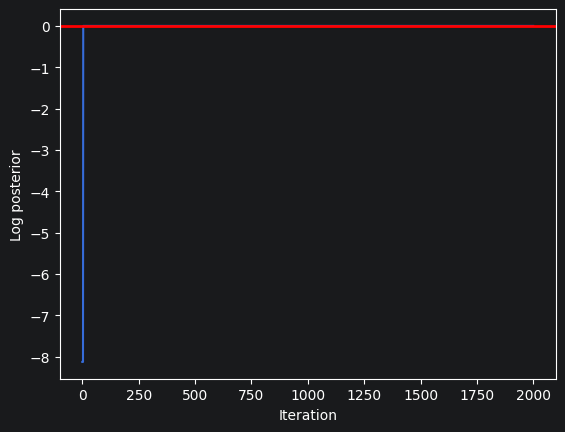

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[0]) - true_posteriors[0]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

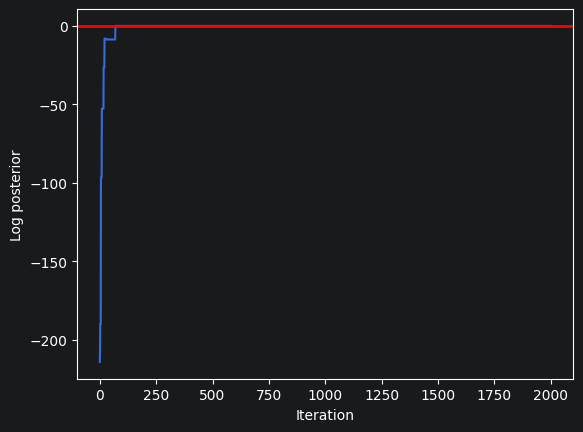

In [51]:
ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[1]) - true_posteriors[1]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

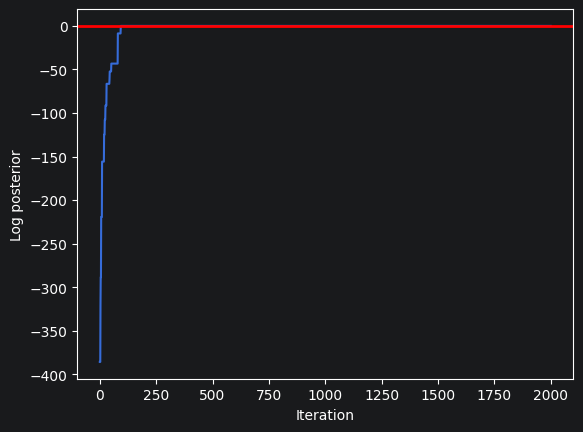

In [52]:
ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[2]) - true_posteriors[2]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

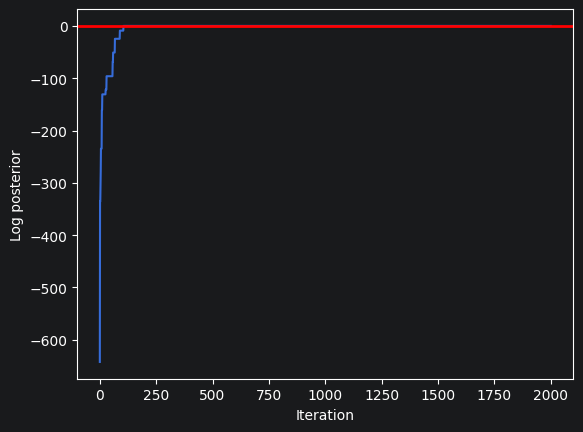

In [53]:
ax = sns.lineplot(x=range(20*(p**2) + 1), y=(np.array(log_posteriors[3]) - true_posteriors[3]))
ax.axhline(y=0, color="red", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Log posterior")
plt.show()

### 50 Chain Analysis (standard parameters with p=10, n=1000)

In [54]:
p = 10
sigma = np.arange(p)
np.random.shuffle(sigma)

sigma

array([0, 6, 3, 1, 2, 8, 7, 9, 5, 4])

In [58]:
hds = []
hds2 = []
hds3 = []
hds4 = []

tau_stars_K1 = []
tau_stars_K5 = []
tau_stars_K10 = []
tau_stars_K20 = []

predicted_orderings_list = []
predicted_dags_list = []
log_posteriors_list = []

true_dags_list = []
true_datasets_list = []
true_posteriors_list = []

for i in range(50):
    print(f"\nStarting Chain: {i+1}\n")
    sim = Simulation(sigma=sigma, n_k=1000, K_list=[1, 5, 10, 20], verbose=True)

    predicted_orderings, predicted_dags, log_posteriors = sim.simulate()
    predicted_orderings_list.append(predicted_orderings)
    predicted_dags_list.append(predicted_dags)
    log_posteriors_list.append(log_posteriors)

    true_dags_list.append(sim.get_true_dags())
    true_datasets_list.append(sim.get_datasets())
    true_posteriors_list.append(sim.get_true_posterior())


    true_adj_matrices = np.array(get_adj_matrix(true_dags[:1]))
    true_adj_matrices2 = np.array(get_adj_matrix(true_dags[:5]))
    true_adj_matrices3 = np.array(get_adj_matrix(true_dags[:10]))
    true_adj_matrices4 = np.array(get_adj_matrix(true_dags[:20]))

    predicted_adj_matrices = np.array([get_adj_matrix(dags) for dags in predicted_dags[0]])
    predicted_adj_matrices2 = np.array([get_adj_matrix(dags) for dags in predicted_dags[1]])
    predicted_adj_matrices3 = np.array([get_adj_matrix(dags) for dags in predicted_dags[2]])
    predicted_adj_matrices4 = np.array([get_adj_matrix(dags) for dags in predicted_dags[3]])

    hds.append(np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices]))
    hds2.append(np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2]))
    hds3.append(np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3]))
    hds4.append(np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4]))

    tau_stars_K1.append(rank_correlation(predicted_orderings[0], sigma))
    tau_stars_K5.append(rank_correlation(predicted_orderings[1], sigma))
    tau_stars_K10.append(rank_correlation(predicted_orderings[2], sigma))
    tau_stars_K20.append(rank_correlation(predicted_orderings[3], sigma))


Starting Chain: 1


K=1 being computed ...



MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:13<00:00, 142.92it/s]



K=5 being computed ...



2026-08-27 23:53:58,522	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-27 23:53:58,532	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-27 23:53:58,535	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-27 23:53:58,536	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:17<00:00, 113.25it/s]



K=10 being computed ...



...

2026-08-28 01:27:15,064	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-28 01:27:15,075	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-28 01:27:15,079	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-28 01:27:15,081	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:16<00:00, 120.44it/s]



K=10 being computed ...



2026-08-28 01:27:36,938	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-28 01:27:36,949	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-28 01:27:36,953	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-28 01:27:36,954	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:24<00:00, 80.71it/s]



K=20 being computed ...



2026-08-28 01:28:06,038	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-28 01:28:06,049	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-28 01:28:06,053	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-28 01:28:06,054	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 2000/2000 [00:40<00:00, 49.09it/s]


In [59]:
mean_hd = np.mean(hds)
mean_hd2 = np.mean(hds2)
mean_hd3 = np.mean(hds3)
mean_hd4 = np.mean(hds4)

std_1_hd = np.std(hds, ddof=1)
std_1_hd2 = np.std(hds2, ddof=1)
std_1_hd3 = np.std(hds3, ddof=1)
std_1_hd4 = np.std(hds4, ddof=1)

print(f"Hamming distance (K=1): {mean_hd} += {std_1_hd}")
print(f"Hamming distance (K=5): {mean_hd2} += {std_1_hd2}")
print(f"Hamming distance (K=10): {mean_hd3} += {std_1_hd3}")
print(f"Hamming distance (K=20): {mean_hd4} += {std_1_hd4}")

Hamming distance (K=1): 11.630719999999998 += 2.2010605239756766
Hamming distance (K=5): 11.7192 += 1.020040787499826
Hamming distance (K=10): 11.888014 += 0.6934742930391301
Hamming distance (K=20): 12.125235 += 0.45924007418756124


In [77]:
mean_tau = np.mean(tau_stars_K1)
mean_tau2 = np.mean(tau_stars_K5)
mean_tau3 = np.mean(tau_stars_K10)
mean_tau4 = np.mean(tau_stars_K20)

se_tau = np.std(tau_stars_K1, ddof=1) / np.sqrt(len(tau_stars_K1))
se_tau2 = np.std(tau_stars_K5, ddof=1) / np.sqrt(len(tau_stars_K5))
se_tau3 = np.std(tau_stars_K10, ddof=1) / np.sqrt(len(tau_stars_K10))
se_tau4 = np.std(tau_stars_K20, ddof=1) / np.sqrt(len(tau_stars_K20))

print(f"Rank Correlation (K=1): {mean_tau} += {se_tau}")
print(f"Rank Correlation (K=5): {mean_tau2} += {se_tau2}")
print(f"Rank Correlation (K=10): {mean_tau3} += {se_tau3}")
print(f"Rank Correlation (K=20): {mean_tau4} += {se_tau4}")

Rank Correlation (K=1): 0.22052444444444397 += 0.022739223482909226
Rank Correlation (K=5): 0.7138568888888878 += 0.017177380747260686
Rank Correlation (K=10): 0.8551831111111119 += 0.010181429234579945
Rank Correlation (K=20): 0.9306595555555548 += 0.004561974944616596


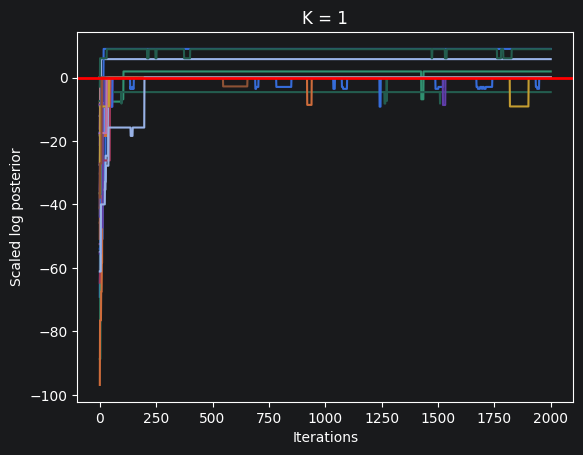

In [63]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][0]) - true_posteriors_list[i][0]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 1")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

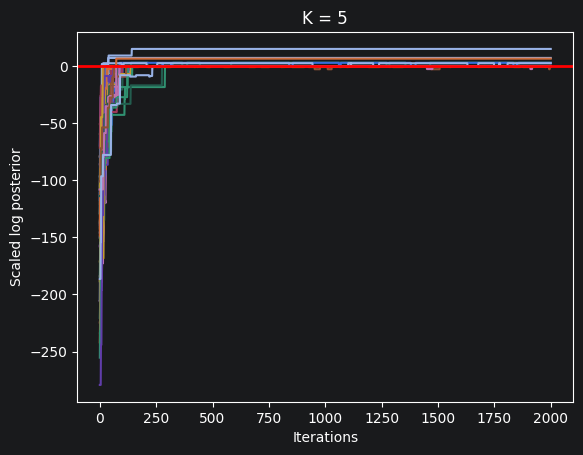

In [64]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][1]) - true_posteriors_list[i][1]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 5")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

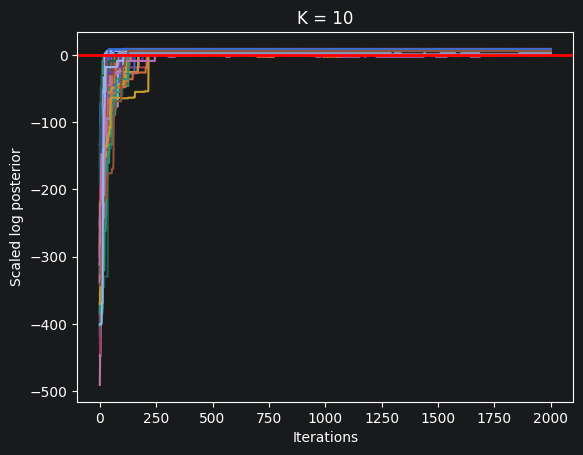

In [65]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][2]) - true_posteriors_list[i][2]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 10")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

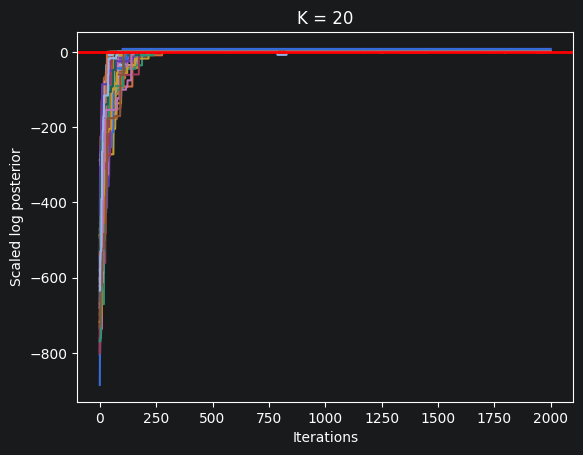

In [66]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][3]) - true_posteriors_list[i][3]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 20")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

In [67]:
def get_adj_matrix_updated(list_dags):
    return [nx.adjacency_matrix(dag, nodelist=range(p), weight=None) for dag in list_dags]

In [74]:
hds_corrected = []
hds2_corrected = []
hds3_corrected = []
hds4_corrected = []

for i in range(50):
    true_adj_matrices = np.array(get_adj_matrix(true_dags_list[i][:1]))
    true_adj_matrices2 = np.array(get_adj_matrix(true_dags_list[i][:5]))
    true_adj_matrices3 = np.array(get_adj_matrix(true_dags_list[i][:10]))
    true_adj_matrices4 = np.array(get_adj_matrix(true_dags_list[i][:20]))

    predicted_adj_matrices = np.array([get_adj_matrix(dags) for dags in predicted_dags_list[i][0]])
    predicted_adj_matrices2 = np.array([get_adj_matrix(dags) for dags in predicted_dags_list[i][1]])
    predicted_adj_matrices3 = np.array([get_adj_matrix(dags) for dags in predicted_dags_list[i][2]])
    predicted_adj_matrices4 = np.array([get_adj_matrix(dags) for dags in predicted_dags_list[i][3]])

    hds_corrected.append(np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices]))
    hds2_corrected.append(np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2]))
    hds3_corrected.append(np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3]))
    hds4_corrected.append(np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4]))

In [78]:
mean_hd_corrected = np.mean(hds_corrected )
mean_hd2_corrected  = np.mean(hds2_corrected )
mean_hd3_corrected  = np.mean(hds3_corrected )
mean_hd4_corrected  = np.mean(hds4_corrected )

se_hd_corrected = np.std(hds_corrected, ddof=1) / np.sqrt(len(hds_corrected))
se_hd2_corrected = np.std(hds2_corrected, ddof=1) / np.sqrt(len(hds2_corrected))
se_hd3_corrected = np.std(hds3_corrected, ddof=1) / np.sqrt(len(hds3_corrected))
se_hd4_corrected = np.std(hds4_corrected, ddof=1) / np.sqrt(len(hds4_corrected))

print(f"Hamming distance (K=1): {mean_hd_corrected } += {se_hd_corrected }")
print(f"Hamming distance (K=5): {mean_hd2_corrected } += {se_hd2_corrected }")
print(f"Hamming distance (K=10): {mean_hd3_corrected } += {se_hd3_corrected }")
print(f"Hamming distance (K=20): {mean_hd4_corrected } += {se_hd4_corrected }")

Hamming distance (K=1): 2.78728 += 0.2318535358226598
Hamming distance (K=5): 1.0924 += 0.07797386835946242
Hamming distance (K=10): 0.6937379999999999 += 0.06077052769095176
Hamming distance (K=20): 0.3854809999999999 += 0.02324422468933226


### 50 Chain Analysis (standard parameters with p=5, n=1000)

In [96]:
p = 5
sigma = np.arange(p)
np.random.shuffle(sigma)

sigma

array([0, 2, 3, 4, 1])

In [98]:
def get_adj_matrix2(list_dags, num_nodes):
    return [nx.adjacency_matrix(dag, nodelist=range(num_nodes), weight=None) for dag in list_dags]

In [99]:
hds = []
hds2 = []
hds3 = []
hds4 = []

tau_stars_K1 = []
tau_stars_K5 = []
tau_stars_K10 = []
tau_stars_K20 = []

predicted_orderings_list = []
predicted_dags_list = []
log_posteriors_list = []

true_dags_list = []
true_datasets_list = []
true_posteriors_list = []

for i in range(50):
    print(f"\nStarting Chain: {i+1}\n")
    sim = Simulation(sigma=sigma, n_k=1000, K_list=[1, 5, 10, 20], verbose=True)

    predicted_orderings, predicted_dags, log_posteriors = sim.simulate()
    predicted_orderings_list.append(predicted_orderings)
    predicted_dags_list.append(predicted_dags)
    log_posteriors_list.append(log_posteriors)

    true_dags = sim.get_true_dags()
    true_dags_list.append(true_dags)
    true_datasets_list.append(sim.get_datasets())
    true_posteriors_list.append(sim.get_true_posterior())

    true_adj_matrices = np.array(get_adj_matrix2(true_dags[:1], p))
    true_adj_matrices2 = np.array(get_adj_matrix2(true_dags[:5], p))
    true_adj_matrices3 = np.array(get_adj_matrix2(true_dags[:10], p))
    true_adj_matrices4 = np.array(get_adj_matrix2(true_dags[:20], p))

    predicted_adj_matrices = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[0]])
    predicted_adj_matrices2 = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[1]])
    predicted_adj_matrices3 = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[2]])
    predicted_adj_matrices4 = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[3]])

    hds.append(np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices]))
    hds2.append(np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2]))
    hds3.append(np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3]))
    hds4.append(np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4]))

    tau_stars_K1.append(rank_correlation(predicted_orderings[0], sigma))
    tau_stars_K5.append(rank_correlation(predicted_orderings[1], sigma))
    tau_stars_K10.append(rank_correlation(predicted_orderings[2], sigma))
    tau_stars_K20.append(rank_correlation(predicted_orderings[3], sigma))


Starting Chain: 1


K=1 being computed ...



2026-08-29 07:16:11,917	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 07:16:11,936	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 07:16:11,939	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 07:16:11,940	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 500/500 [00:01<00:00, 369.52it/s]



K=5 being computed ...



2026-08-29 07:16:18,663	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 07:16:18,676	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 07:16:18,680	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 07:16:18,681	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 500/500 [00:01<00:00, 268.70it/s]



K=10 being computed ...



...

2026-08-29 07:40:15,558	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 07:40:15,568	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 07:40:15,573	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 07:40:15,574	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 500/500 [00:01<00:00, 291.84it/s]



K=10 being computed ...



2026-08-29 07:40:21,475	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 07:40:21,485	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 07:40:21,489	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 07:40:21,490	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 500/500 [00:02<00:00, 190.11it/s]



K=20 being computed ...



2026-08-29 07:40:28,465	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 07:40:28,477	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 07:40:28,481	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 07:40:28,482	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 500/500 [00:04<00:00, 103.72it/s]


In [100]:
mean_tau = np.mean(tau_stars_K1)
mean_tau2 = np.mean(tau_stars_K5)
mean_tau3 = np.mean(tau_stars_K10)
mean_tau4 = np.mean(tau_stars_K20)

se_tau = np.std(tau_stars_K1, ddof=1) / np.sqrt(len(tau_stars_K1))
se_tau2 = np.std(tau_stars_K5, ddof=1) / np.sqrt(len(tau_stars_K5))
se_tau3 = np.std(tau_stars_K10, ddof=1) / np.sqrt(len(tau_stars_K10))
se_tau4 = np.std(tau_stars_K20, ddof=1) / np.sqrt(len(tau_stars_K20))

print(f"Rank Correlation (K=1): {mean_tau} += {se_tau}")
print(f"Rank Correlation (K=5): {mean_tau2} += {se_tau2}")
print(f"Rank Correlation (K=10): {mean_tau3} += {se_tau3}")
print(f"Rank Correlation (K=20): {mean_tau4} += {se_tau4}")

Rank Correlation (K=1): 0.29744000000000004 += 0.031859339834558374
Rank Correlation (K=5): 0.6998720000000003 += 0.02617315886981342
Rank Correlation (K=10): 0.8149920000000015 += 0.01965559874333996
Rank Correlation (K=20): 0.8815040000000016 += 0.010003901671501066


In [101]:
mean_hd = np.mean(hds)
mean_hd2  = np.mean(hds2)
mean_hd3  = np.mean(hds3)
mean_hd4  = np.mean(hds4)

se_hd_corrected = np.std(hds, ddof=1) / np.sqrt(len(hds))
se_hd2_corrected = np.std(hds2, ddof=1) / np.sqrt(len(hds2))
se_hd3_corrected = np.std(hds3, ddof=1) / np.sqrt(len(hds3))
se_hd4_corrected = np.std(hds4, ddof=1) / np.sqrt(len(hds4))

print(f"Hamming distance (K=1): {mean_hd } += {se_hd_corrected }")
print(f"Hamming distance (K=5): {mean_hd2 } += {se_hd2_corrected }")
print(f"Hamming distance (K=10): {mean_hd3 } += {se_hd3_corrected }")
print(f"Hamming distance (K=20): {mean_hd4 } += {se_hd4_corrected }")

Hamming distance (K=1): 1.7491999999999999 += 0.20939111729010854
Hamming distance (K=5): 0.922544 += 0.10036085927678931
Hamming distance (K=10): 0.6595840000000002 += 0.07824235125217918
Hamming distance (K=20): 0.469296 += 0.040099473960619074


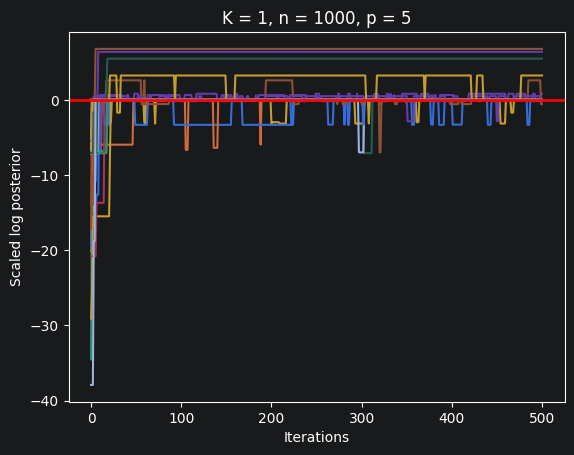

In [110]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][0]) - true_posteriors_list[i][0]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 1, n = 1000, p = 5")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

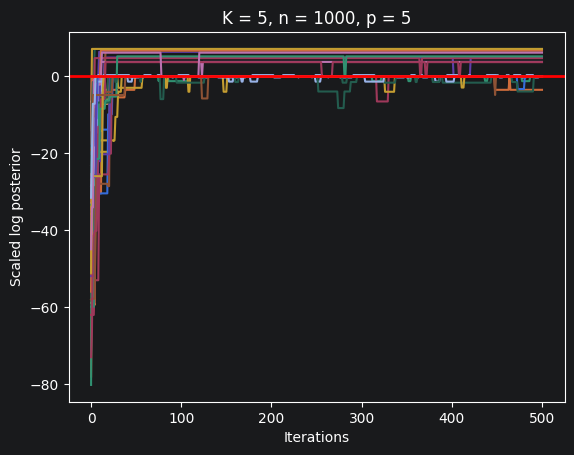

In [111]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][1]) - true_posteriors_list[i][1]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 5, n = 1000, p = 5")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

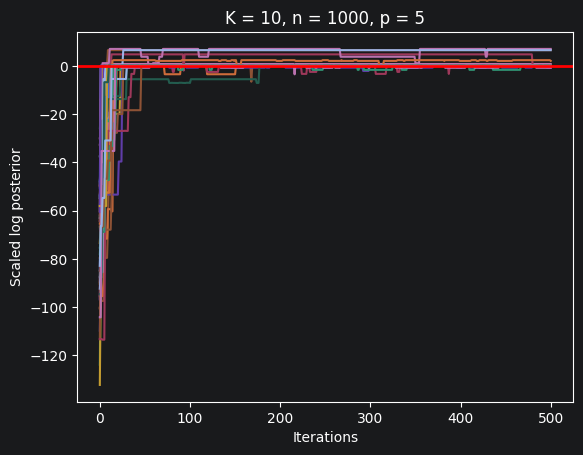

In [112]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][2]) - true_posteriors_list[i][2]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 10, n = 1000, p = 5")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

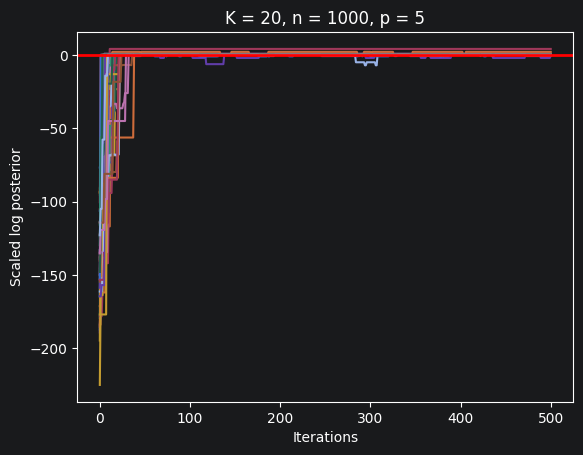

In [113]:
for i in range(50):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][3]) - true_posteriors_list[i][3]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 20, n = 1000, p = 5")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

### 20 Chain Analysis (standard parameters with p=20, n=1000)

In [85]:
p = 20
sigma = np.arange(p)
np.random.shuffle(sigma)

sigma

array([ 7, 15,  5, 11, 16, 17, 19,  8, 12, 13,  0,  2, 10,  3,  1, 14,  6,
        9,  4, 18])

In [86]:
def get_adj_matrix2(list_dags, num_nodes):
    return [nx.adjacency_matrix(dag, nodelist=range(num_nodes), weight=None) for dag in list_dags]

In [87]:
hds = []
hds2 = []
hds3 = []
hds4 = []

tau_stars_K1 = []
tau_stars_K5 = []
tau_stars_K10 = []
tau_stars_K20 = []

predicted_orderings_list = []
predicted_dags_list = []
log_posteriors_list = []

true_dags_list = []
true_datasets_list = []
true_posteriors_list = []

for i in range(20):
    print(f"\nStarting Chain: {i+1}\n")
    sim = Simulation(sigma=sigma, n_k=1000, K_list=[1, 5, 10, 20], verbose=True)

    predicted_orderings, predicted_dags, log_posteriors = sim.simulate()
    predicted_orderings_list.append(predicted_orderings)
    predicted_dags_list.append(predicted_dags)
    log_posteriors_list.append(log_posteriors)

    true_dags = sim.get_true_dags()
    true_dags_list.append(true_dags)
    true_datasets_list.append(sim.get_datasets())
    true_posteriors_list.append(sim.get_true_posterior())

    true_adj_matrices = np.array(get_adj_matrix2(true_dags[:1], p))
    true_adj_matrices2 = np.array(get_adj_matrix2(true_dags[:5], p))
    true_adj_matrices3 = np.array(get_adj_matrix2(true_dags[:10], p))
    true_adj_matrices4 = np.array(get_adj_matrix2(true_dags[:20], p))

    predicted_adj_matrices = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[0]])
    predicted_adj_matrices2 = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[1]])
    predicted_adj_matrices3 = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[2]])
    predicted_adj_matrices4 = np.array([get_adj_matrix2(dags, p) for dags in predicted_dags[3]])

    hds.append(np.mean([hamming_distance(predicted, true_adj_matrices) for predicted in predicted_adj_matrices]))
    hds2.append(np.mean([hamming_distance(predicted, true_adj_matrices2) for predicted in predicted_adj_matrices2]))
    hds3.append(np.mean([hamming_distance(predicted, true_adj_matrices3) for predicted in predicted_adj_matrices3]))
    hds4.append(np.mean([hamming_distance(predicted, true_adj_matrices4) for predicted in predicted_adj_matrices4]))

    tau_stars_K1.append(rank_correlation(predicted_orderings[0], sigma))
    tau_stars_K5.append(rank_correlation(predicted_orderings[1], sigma))
    tau_stars_K10.append(rank_correlation(predicted_orderings[2], sigma))
    tau_stars_K20.append(rank_correlation(predicted_orderings[3], sigma))


Starting Chain: 1


K=1 being computed ...



2026-08-28 22:07:46,892	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-28 22:07:46,898	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-28 22:07:46,900	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-28 22:07:46,900	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 8000/8000 [02:47<00:00, 47.64it/s]



K=5 being computed ...



2026-08-28 22:10:40,206	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-28 22:10:40,216	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-28 22:10:40,221	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-28 22:10:40,222	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 8000/8000 [03:11<00:00, 41.77it/s]



K=10 being computed ...



...

2026-08-29 05:09:16,922	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 05:09:16,933	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 05:09:16,937	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 05:09:16,938	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 8000/8000 [03:34<00:00, 37.32it/s]



K=10 being computed ...



2026-08-29 05:12:55,746	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 05:12:55,756	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 05:12:55,760	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 05:12:55,761	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 8000/8000 [04:46<00:00, 27.94it/s]



K=20 being computed ...



2026-08-29 05:17:46,766	INFO worker.py:2024 -- Started a local Ray instance.
2026-08-29 05:17:46,778	INFO packaging.py:734 -- Creating a file package for local module '/Users/sreehari_miniravi/Work/ResearchProjects/bayesian-multi-dag/bayesian_order_based_learning'.
2026-08-29 05:17:46,782	INFO packaging.py:434 -- Pushing file package 'gcs://_ray_pkg_2df56b6702fab504.zip' (0.01MiB) to Ray cluster...
2026-08-29 05:17:46,783	INFO packaging.py:447 -- Successfully pushed file package 'gcs://_ray_pkg_2df56b6702fab504.zip'.
MCMC Sampling wth R2R: 100%|██████████| 8000/8000 [06:53<00:00, 19.34it/s]


In [88]:
mean_tau = np.mean(tau_stars_K1)
mean_tau2 = np.mean(tau_stars_K5)
mean_tau3 = np.mean(tau_stars_K10)
mean_tau4 = np.mean(tau_stars_K20)

se_tau = np.std(tau_stars_K1, ddof=1) / np.sqrt(len(tau_stars_K1))
se_tau2 = np.std(tau_stars_K5, ddof=1) / np.sqrt(len(tau_stars_K5))
se_tau3 = np.std(tau_stars_K10, ddof=1) / np.sqrt(len(tau_stars_K10))
se_tau4 = np.std(tau_stars_K20, ddof=1) / np.sqrt(len(tau_stars_K20))

print(f"Rank Correlation (K=1): {mean_tau} += {se_tau}")
print(f"Rank Correlation (K=5): {mean_tau2} += {se_tau2}")
print(f"Rank Correlation (K=10): {mean_tau3} += {se_tau3}")
print(f"Rank Correlation (K=20): {mean_tau4} += {se_tau4}")

Rank Correlation (K=1): 0.24309500000000103 += 0.02312467655006826
Rank Correlation (K=5): 0.6634678947368486 += 0.016565987221675182
Rank Correlation (K=10): 0.8162556578947499 += 0.01151497807420335
Rank Correlation (K=20): 0.9154127631579065 += 0.005998708006747565


In [89]:
mean_hd = np.mean(hds)
mean_hd2  = np.mean(hds2)
mean_hd3  = np.mean(hds3)
mean_hd4  = np.mean(hds4)

se_hd_corrected = np.std(hds, ddof=1) / np.sqrt(len(hds))
se_hd2_corrected = np.std(hds2, ddof=1) / np.sqrt(len(hds2))
se_hd3_corrected = np.std(hds3, ddof=1) / np.sqrt(len(hds3))
se_hd4_corrected = np.std(hds4, ddof=1) / np.sqrt(len(hds4))

print(f"Hamming distance (K=1): {mean_hd } += {se_hd_corrected }")
print(f"Hamming distance (K=5): {mean_hd2 } += {se_hd2_corrected }")
print(f"Hamming distance (K=10): {mean_hd3 } += {se_hd3_corrected }")
print(f"Hamming distance (K=20): {mean_hd4 } += {se_hd4_corrected }")

Hamming distance (K=1): 4.46045 += 0.48005658643977633
Hamming distance (K=5): 2.1696425 += 0.16556101615237778
Hamming distance (K=10): 1.33660375 += 0.09619147677862096
Hamming distance (K=20): 0.7059093750000001 += 0.05699962102305772


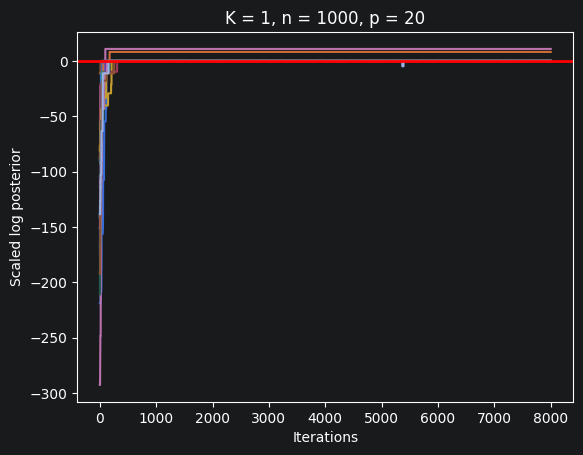

In [91]:
for i in range(20):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][0]) - true_posteriors_list[i][0]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 1, n = 1000, p = 20")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

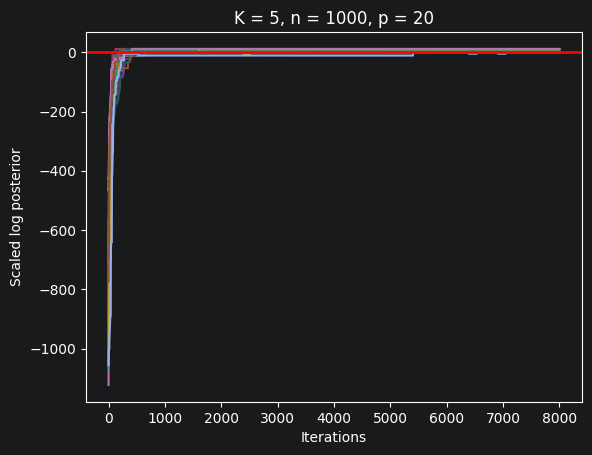

In [93]:
for i in range(20):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][1]) - true_posteriors_list[i][1]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 5, n = 1000, p = 20")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

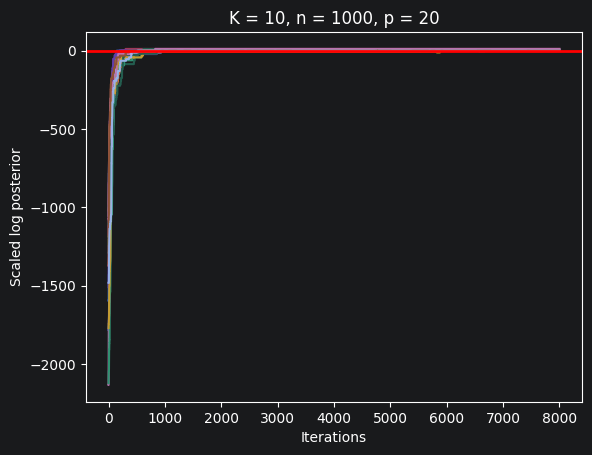

In [94]:
for i in range(20):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][2]) - true_posteriors_list[i][2]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 10, n = 1000, p = 20")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()

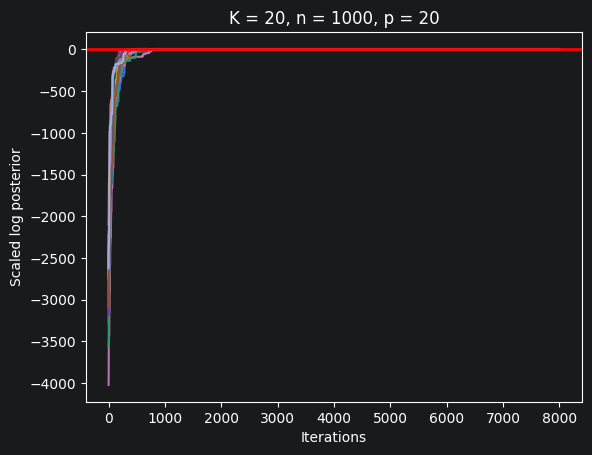

In [95]:
for i in range(20):
    plt.plot(range(20*(p**2) + 1), (np.array(log_posteriors_list[i][3]) - true_posteriors_list[i][3]))
plt.axhline(y=0, color="red", linewidth=2)
plt.title("K = 20, n = 1000, p = 20")
plt.xlabel("Iterations")
plt.ylabel("Scaled log posterior")
plt.show()